# Example of using string loop info

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pyaxions import jaxions as pa
from pyaxions import randomstrings  as rs
from pyaxions import simgen  as sg

import matplotlib as mpl
mpl.rcParams['mathtext.rm'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 16
mpl.rcParams['text.usetex'] = True

import importlib

In [21]:
importlib.reload(pa)

<module 'pyaxions.jaxions' from '/Users/madomaxo/Salsa/jaxions/jaxions/scripts/pyaxions/jaxions.py'>

In [2]:
# make sure mpirun is found
import os
os.environ["PATH"] = "/opt/local/bin:/usr/local/bin:" + os.environ["PATH"]

# Generate a config with a few strings

Here we choose lola atractor ICs, 

To measure loops we need to pass --strmeas 8 

We note that --strmeas 0,1,2,3,4,5,6,7 will trigger a length measurement that does not distinguish loops

with 8 another length measurement is applied that "walks" the strings, labels them and saves:

    - length per string loop 
    - COM coordinates
    - moment of inertia of the string w.r.t COM
    - whether it wraps the periodic box in X,Y,Z directions or nor

using 16 will also save a 3D label map (good for debuggin but not recommended). 
Here we do it for visualisation purposes

In [57]:
# r,jax = sg.simgen(N=256,zRANKS=1,ic='lola',logi=3.0,ict='lola',meas=32+128,steps=0)

rank, jax = sg.simgen(N = 256, L = 3, msa = 1.0, zRANKS = 4, ctf = 2, ic = 'lola', ict = 'lola', prec = 'single',
                      dev = 'cpu', lap = 2, fftplan = 64, fA = -1, vqcd = 'vqcd0', 
                      logi = 3.0, meas = 0, strmeas = 8, spKGV = 0, rmask = 4.0, p3D = 1, 
                      slc = 0, nologmpi = True, verbose = 0, sIter = 0, verb = False, dump = 5, wDz = 1.0)


In [58]:
# sg.runsim(JAX=jax, MODE='create', RANK=r, VERB = True, USA='')
sg.runsim(JAX = jax, RANK = rank, MODE = 'run', THR = 4//rank, USA = '', VERB = True, BONDEN = False)



--------------------------------------------------------------------------------------------
Mode: run 

mpirun  -np 4 -x OMP_NUM_THREADS=1 vaxion3d  --msa 1.000000 --lsize 3.000000 --zf 2.000000 --ind3 0.000000 --qcd 7.000000 --dwgam 1.000000 --size 256 --depth 64 --zgrid 4 --prec single --device cpu --prop rkn4 --steps 1000000 --wDz 1.000000 --sst0 10 --fftplan 64 --lap 2 --vqcd0 --logi 3.000000 --ctype lola --sliceprint 0 --strmeas 8 --dump 5 --meas 0 --p3D 1  --spmask 1 --rmask 4.0 --spKGV 0 --verbose 0 --nologmpi 2>&1 | tee log.txt

-------------------------------------------------

--               VAXION 3D!                    --

-------------------------------------------------

Generating scalar ... Done! 
ICtime 0.056367 min
--------------------------------------------------
        SIMULATION (256 x 256 x 64)  x 4 

Box Length [1/R1H1]      =  3.00
dx                       =  0.01172
dz                       =  1.00/FREQ

FRW scale factor (R)     =  z^1.00 

Saxion self-c

# Read and plot

In [67]:
# measurement files
mf = pa.findmfiles('out/m')
print(mf[0],mf[-1])

out/m/axion.m.00000 out/m/axion.m.00110


In [64]:
#helpers for the plot 
def inertia_to_second_moment(I6):
    # I6 = [Ixx, Iyy, Izz, Ixy, Ixz, Iyz]
    Ixx, Iyy, Izz, Ixy, Ixz, Iyz = I6
    I = np.array([[Ixx, Ixy, Ixz],
                  [Ixy, Iyy, Iyz],
                  [Ixz, Iyz, Izz]], dtype=float)
    trI = np.trace(I)
    M = 0.5 * trI * np.eye(3) - I
    return M

def draw_cov_ellipse(ax, center, C2, color, k=2.0, npts=200, **plot_kw):
    # Eigen-decompose 2x2 covariance and plot k-sigma ellipse
    evals, evecs = np.linalg.eigh(C2)
    evals = np.maximum(evals, 0.0)             # numerical safety
    radii = k * np.sqrt(evals)
    t = np.linspace(0, 2*np.pi, npts)
    circle = np.stack([np.cos(t), np.sin(t)], axis=0)  # 2 x n
    R = evecs @ np.diag(radii)
    pts = (R @ circle).T + np.asarray(center)[None, :]
    ax.plot(pts[:,0], pts[:,1], c=color, **plot_kw)

# Plot the loops 
    - label, 
    - COM with X 
    - ellipsoid from the moment of inertia 

loop coordinates are saves unwrapped in the torus, 

label map produces wrapped coordinates... do not get fret!

No label MAP
TOTAL # LOOPS 
We print %d 5
LABEL 1 length 1018.21
wrapped? False
cood exut  [106.  73.   0.] [106.  73.   0.]


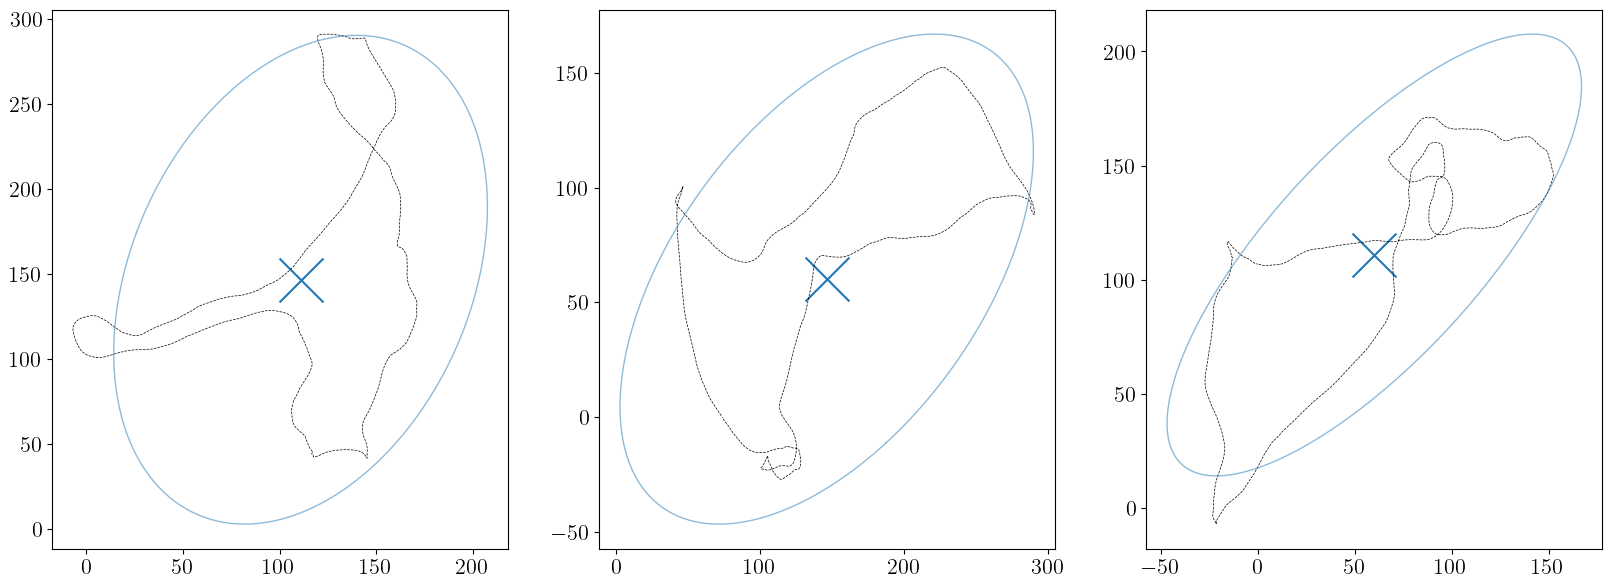

LABEL 2 length 306.86
wrapped? False
cood exut  [234. 221.  55.] [234. 221.  55.]


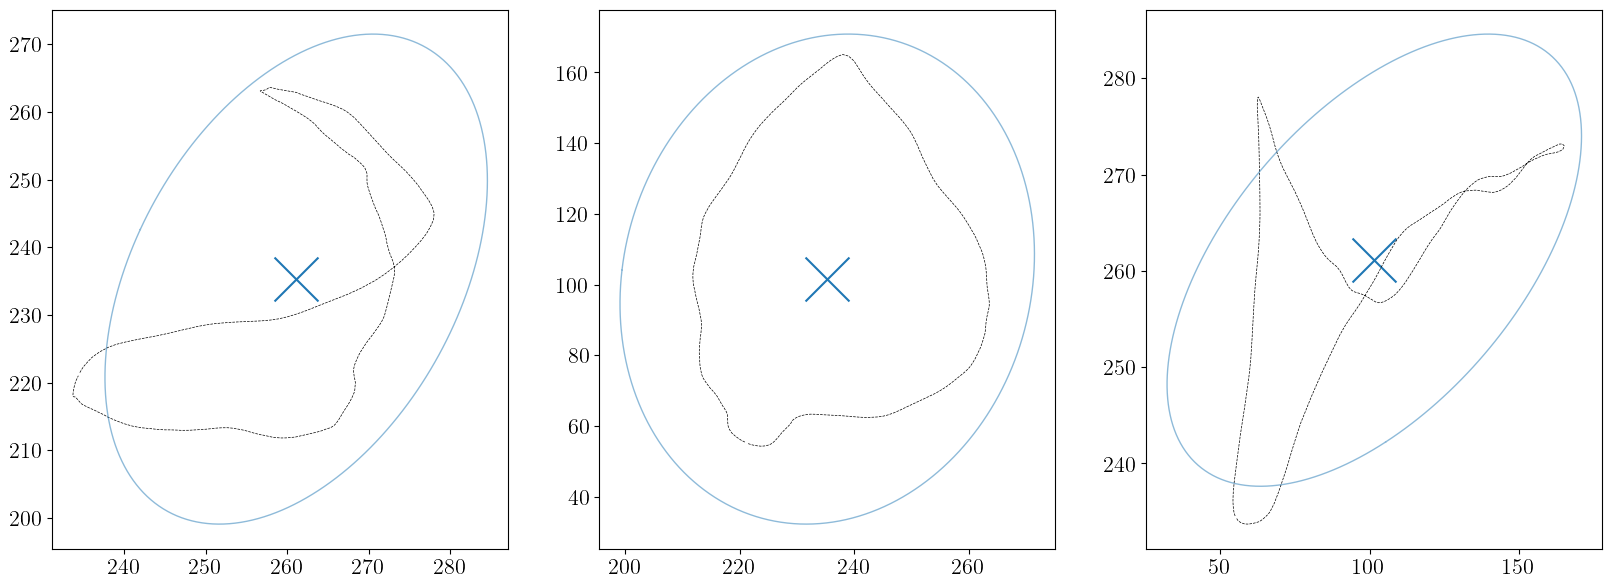

LABEL 5 length 19.26
wrapped? False
cood exut  [ 18. 237. 170.] [ 18. 237. 171.]


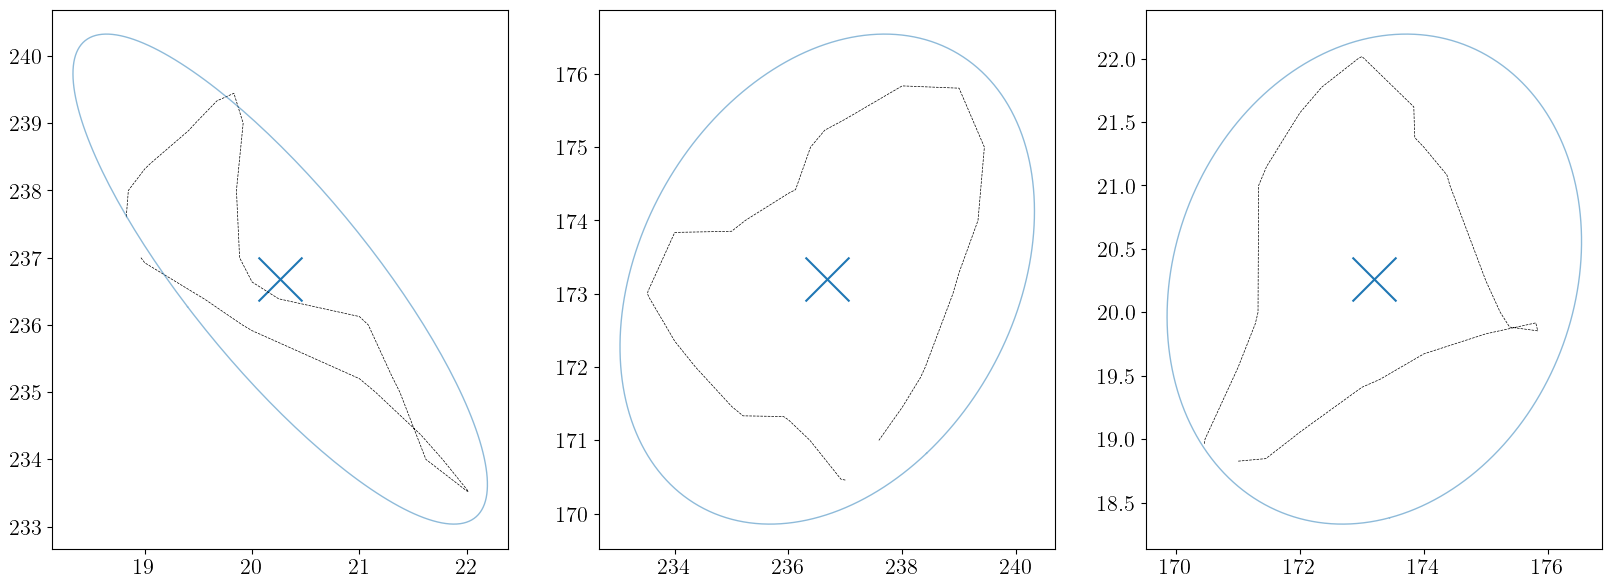

LABEL 4 length 11.67
wrapped? False
cood exut  [ 16. 123. 123.] [ 17. 123. 123.]


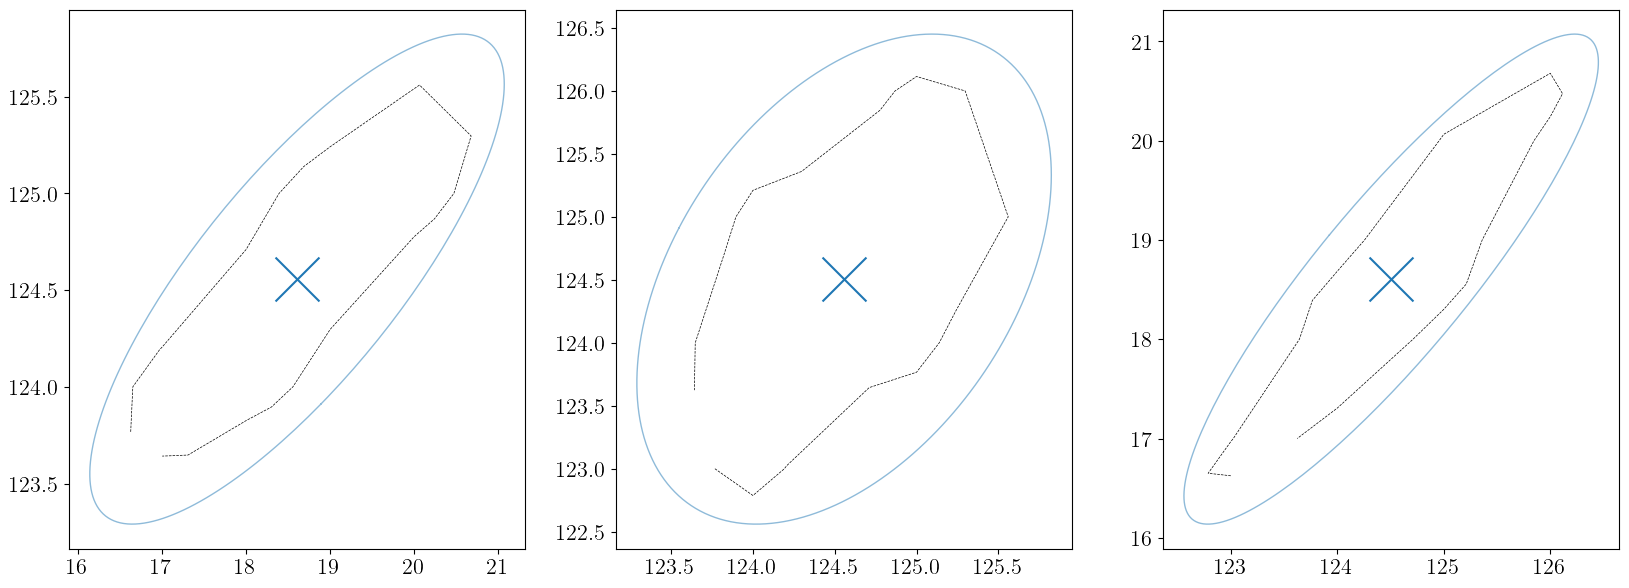

LABEL 3 length 2.72
wrapped? False
cood exut  [  3. 121. 115.] [  4. 121. 115.]


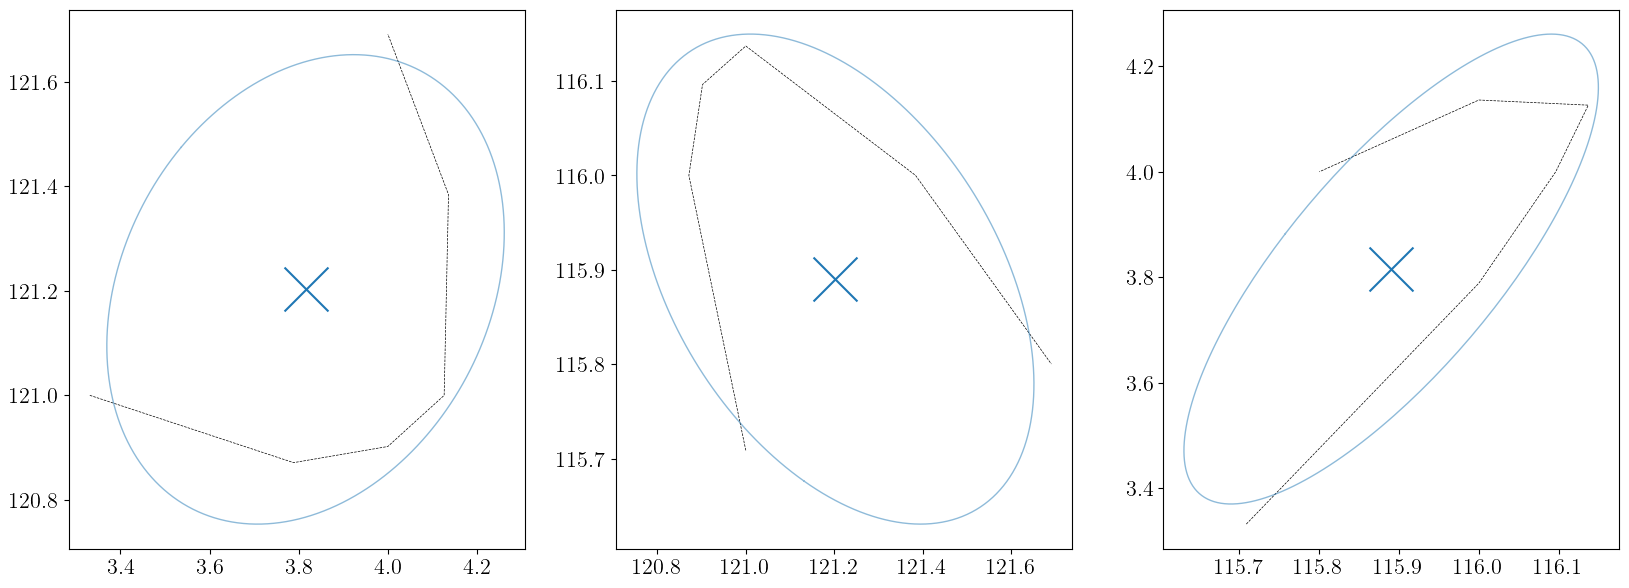

In [193]:
it = -2
N = pa.gm(mf[it],'N')
labelmap = pa.gm(mf[it],'stLabels?')
loops    = pa.gm(mf[it],'stloops?')
if labelmap:
    ld = np.reshape(pa.gm(mf[it],'stLabels'),(N,N,N))
else: 
    print("No label MAP")
if loops:
    d = pa.gm(mf[it],'stloops')
    com = d['com_coords']+d['origin']
else: 
    print("Somthing went amiss... loops not computed ... QUIT and TRY BETTER!")

def break_long_jumps_2d(x, y, max_gap=2.0):
    x = np.asarray(x); y = np.asarray(y)
    d = np.hypot(np.diff(x), np.diff(y))          # segment lengths
    cut = np.where(d > max_gap)[0] + 1            # indices to break *after*
    x2 = np.insert(x, cut, np.nan)
    y2 = np.insert(y, cut, np.nan)
    return x2, y2

L = len(d["labels"])
print("TOTAL # LOOPS ",)
p = min(10,L)
r = L//p
print("We print %d",p)
for i in range(0,L,r):
    fig,ax=plt.subplots(1,3,figsize=(20,7))
    label=d["labels"][i]
    cof='C0'

    if labelmap:
        z, y, x = (ld == label).nonzero()
        print("contained",x.min(),x.max(),y.min(),y.max(),z.min(),z.max())
        pos = np.array([z,y,x]).transpose()
        ax[0].scatter(x,y,c=cof,s=10,alpha=0.1)
        ax[1].scatter(y,z,c=cof,s=10,alpha=0.1)
        ax[2].scatter(z,x,c=cof,s=10,alpha=0.1)
    
    XX,YY = break_long_jumps_2d(d['coords'][i][:,0],d['coords'][i][:,1])
    ax[0].plot(XX,YY,'--',c='k',lw=0.5)
    YY,ZZ = break_long_jumps_2d(d['coords'][i][:,1],d['coords'][i][:,2])
    ax[1].plot(YY,ZZ,'--',c='k',lw=0.5)
    ZZ,XX = break_long_jumps_2d(d['coords'][i][:,2],d['coords'][i][:,0])
    ax[2].plot(ZZ,XX,'--',c='k',lw=0.5)
    print("LABEL %d length %.2f"%(label,d['lengths'][i]))
    print("wrapped?",d['closed'][i]>0)
    if (d['closed'][i] < 1):
        ax[0].scatter(com[i,0],com[i,1],color=cof,marker='x',s=1000)
        ax[1].scatter(com[i,1],com[i,2],color=cof,marker='x',s=1000)
        ax[2].scatter(com[i,2],com[i,0],color=cof,marker='x',s=1000)
        # only works good with a sensible COM defined
        I6 = d['inertia'][i]
        M = inertia_to_second_moment(I6)
        S = M / d["lengths"][i]
        S_xy = S[np.ix_([0,1],[0,1])]
        draw_cov_ellipse(ax[0], (com[i,0], com[i,1]), S_xy, color=cof, k=2.0, lw=1, alpha=0.5)
        S_yz = S[np.ix_([1,2],[1,2])]
        draw_cov_ellipse(ax[1], (com[i,1], com[i,2]), S_yz, color=cof, k=2.0, lw=1, alpha=0.5)
        S_zx = S[np.ix_([2,0],[2,0])]
        draw_cov_ellipse(ax[2], (com[i,2], com[i,0]), S_zx, color=cof, k=2.0, lw=1, alpha=0.5)
    print('cood exut ',np.floor(d['coords'][i][0]),np.floor(d['coords'][i][-1]))
    
    plt.show()

# Some statistics

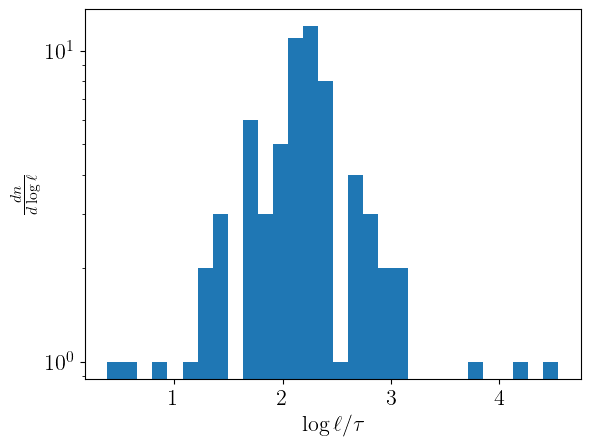

In [72]:
it=10
t0 = pa.gm(mf[it],'ct')
d = pa.gm(mf[it],'stloops')
plt.hist(np.log10(d["lengths"]/t0),30)
plt.yscale('log')
plt.ylabel(r'$\frac{d n}{d \log\ell}$')
plt.xlabel(r'$\log \ell/\tau $')
plt.show()

# Time evolution

In [126]:
f = []
for it in range(len(mf)):
    d = pa.gm(mf[it],'stloops')
    t = pa.gm(mf[it],'ct')
    l = d["lengths"]
    f.append([np.ones_like(l)*t,l])

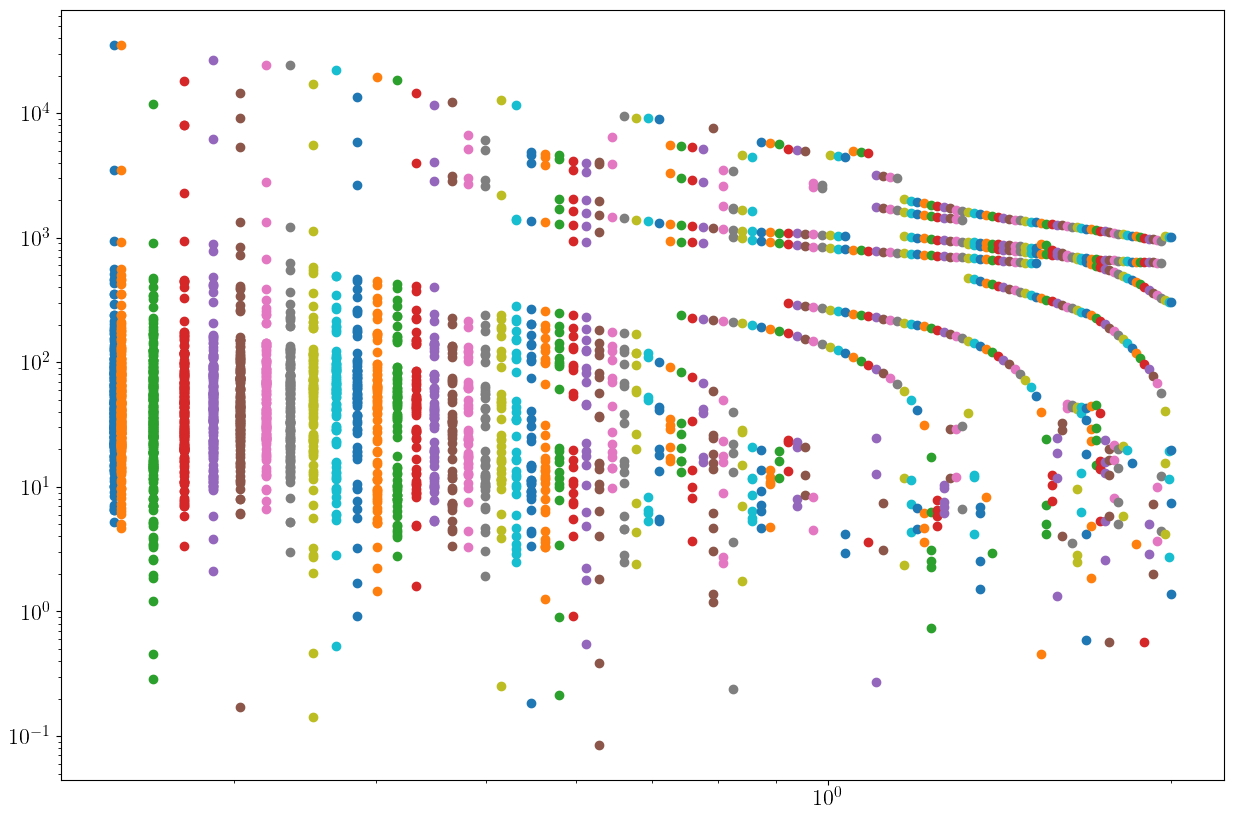

In [127]:
fig,ax=plt.subplots(1,figsize=(15,10))
for it in range(len(mf)):
    plt.scatter(f[it][0],f[it][1])
plt.xscale('log')
plt.yscale('log')

# COM

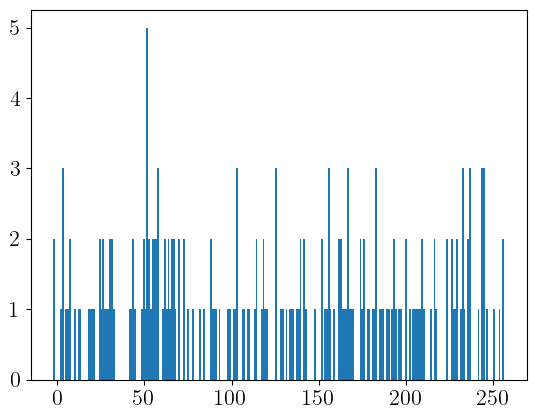

In [143]:
it=1
d = pa.gm(mf[it],'stloops')
f = d["origin"]+d["com_coords"] #wrapcom(d["com_coords"],N)
ff = plt.hist(f[:,0],256)

In [ ]:
# helpers
def wrapcom(x,N):
    return np.mod(x,N)
def wrapdist(x,y,N):
    d = np.mod(x-y,N)
    mask = d < N//2+1
    d = d*mask +(N-d)*(~mask)
    return  np.linalg.norm(d)

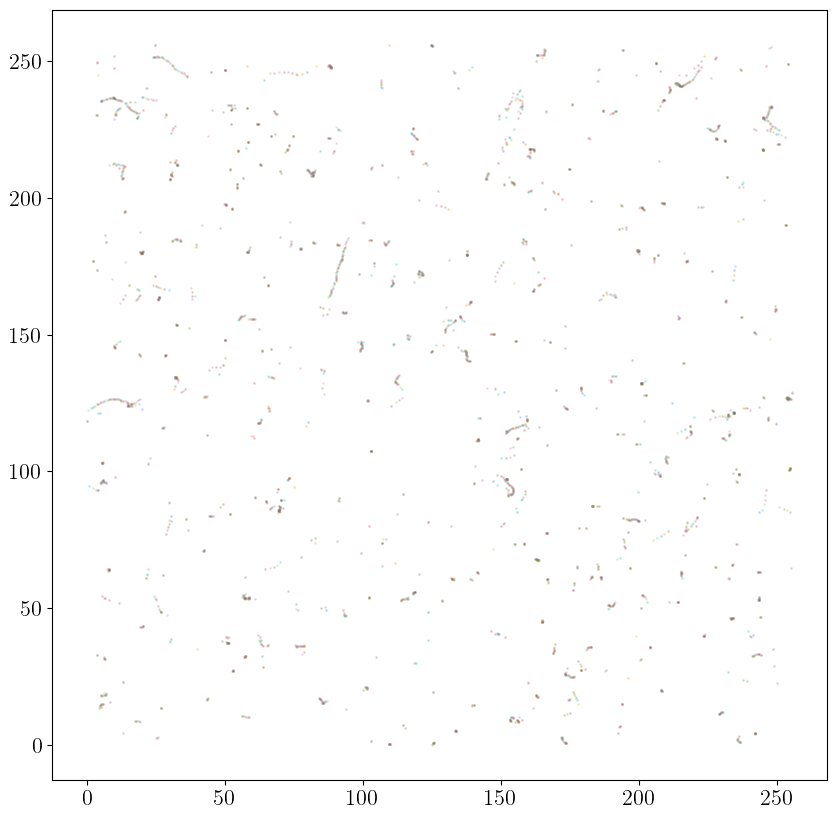

In [146]:
fig,ax=plt.subplots(1,figsize=(10,10))
f = []
for it in range(len(mf)):
    d = pa.gm(mf[it],'stloops')
    t = pa.gm(mf[it],'ct')
    cc = wrapcom(d["origin"]+d["com_coords"],N)
    l  =  d["lengths"]
    cof = 'C'+str(it)
    plt.scatter(cc[:,0],cc[:,1],s=1,alpha=0.2,color=cof)

In [ ]:
fig,ax=plt.subplots(1,figsize=(15,10))
for it in range(len(mf)):
    plt.scatter(f[it][0],f[it][1])
plt.xscale('log')
plt.yscale('log')

# Accross snapshots

# Longest strigns

In [189]:
f = np.zeros((len(mf),10))
c = np.zeros((len(mf),10))
for it in range(len(mf)):
    d = pa.gm(mf[it],'stloops')
    lo = min(len(d["lengths"]),10)
    f[it,:lo] = d["lengths"][:lo]
    c[it,:lo] = np.linalg.norm(wrapcom(d["origin"][:lo]+d["com_coords"][:lo],N),axis=1)
delta = pa.gm(mf[0],'delta')
ct = pa.gml(mf,'ct')/delta

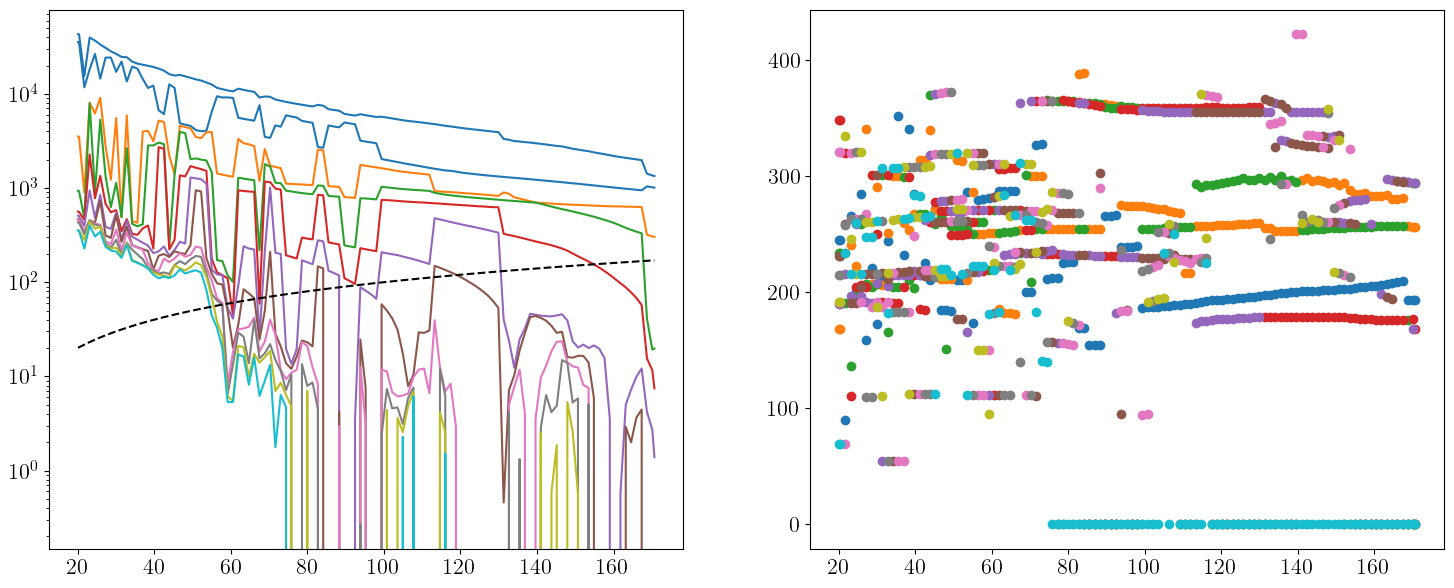

In [192]:
fig,ax=plt.subplots(1,2,figsize=(18,7))

ax[0].semilogy(ct,f)
ax[0].semilogy(ct,f.sum(axis=1))
ax[0].semilogy(ct,ct,'--k')
for i in range(10):
    ax[1].scatter(ct,c[:,i])
plt.show()